# Ajustamento Linear: questao 1 

A tabela mostra os dados de *Vendas Trimestrais (em milhares de R\$) x População Jovem (em milhares)*, de uma franquia de pizzaria. 

\begin{array}{cc}
\text{População}&\text{Vendas}\\ \hline
2  & 58 \\
6  & 105 \\
8  & 88 \\
8  & 118 \\
12  & 117 \\
16  & 137 \\
20  & 157 \\
20  & 169 \\
22  & 149 \\
26  & 202 \\
\end{array}

Para este conjunto de dados:
*   (a) estime a regressão linear (ou ajustamento linear) da forma $P_1(x) = ax + b$ e calcule a projeção das vendas para 30.000 pessoas.
*   (b) estime a regressão linear da forma $P_2(x) = a + bx + cx^2$ e calcule a projeção das vendas para 30.000 
pessoas.
*   (c) estime a regressão linear da forma $P_3(x) = b + a*ln(x) $ e calcule a projeção das vendas para 30.000
*   (d) qual das projeções você utilizaria? 

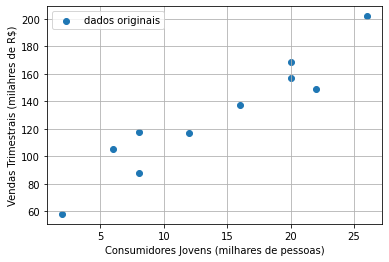

In [12]:
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
plt.scatter(x, f)                 # grafico pontual
plt.legend(['dados originais'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milahres de R$)') 
plt.grid()
plt.show()

*(a)* Assuma uma equação de ajustamento da forma $P(x) = ag_1(x) + bg_0(x)$, onde $g_1(x) = x$ e $g_0(x) = 1$, o que resulta na montagem da seguinte tabela:  
\begin{array}{c|ccccccccc}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$g_0$} &\text{$g_1$} &\text{$g^2_0$}&\text{$g^2_1$}&\text{$g_0g_1$}&\text{$g_0f(x_i)$}&\text{$g_1f(x_i)$}\\ \hline 
0 & 2 & 58 & 1 & 2 & 1 & 4 & 2 & 58 &116 \\
1 & 6 & 105 & 1 & 6 & 1 & 36 & 6 & 105 &630 \\
2 & 8 & 88 & 1 & 8 & 1 & 64 & 8 & 88 & 704 \\
3 & 8 & 118 & 1 & 8 & 1 & 64 & 8 & 118 & 944 \\
4 & 12 & 117 & 1 & 12 & 1 & 144 & 12 & 117 & 1404 \\
5 & 16 & 137 & 1 & 16 & 1 & 256 & 16 & 137 & 2192 \\
6 & 20 & 157 & 1 & 20 & 1 & 400 & 20 & 157 & 3140 \\
7 & 20 & 169 & 1 & 20 & 1 & 400 & 20 & 169 & 3380 \\
8 & 22 & 149 & 1 & 20 & 1 & 484 & 22 & 149 & 2980\\ 
9 & 26 & 202 & 1 & 26 & 1 & 676 & 26 & 202 & 5252 \\
\hline
&&&&\text{$\Sigma =$} & 10 & 2528 & 140 & 1300 & 21040
\end{array}
 
 Portanto, será necessario resolver o sistema de equações lineares: 

 $\left\{
\begin{aligned}
    10a + 140b     &= 1330\\
    140a + 2528b &= 21040
\end{aligned}
\right.$

Cuja solução é $a = 5$ e $b = 60$, de maneira que a função de ajustamento tem a forma $P(x) = 5x + 60$ e a projeção de vendas com 30.000 pessoas é de $P(30) = 5\times30 + 60 = 210$.

P1(x) =  5.0 *x +  60.0    =>
P1(30) =  210.0 



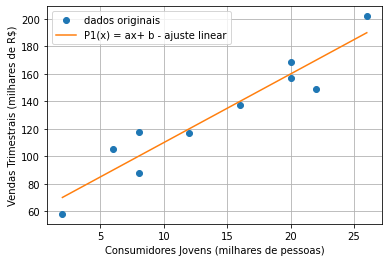

In [13]:
import numpy as np
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
A1 = [[0., 0.],[0., 0.]]  # matriz dos coeficientes do sistema linear
B1 = [0., 0.]

for i in range(len(x)):
  A1[0][0] +=1
  A1[1][1] += x[i]*x[i]
  A1[0][1] += x[i]
  B1[0] += f[i]
  B1[1] += x[i]*f[i]
A1[1][0] = A1[0][1]
[b1, a1] = np.linalg.solve(A1, B1)  # encontrando a solução do sistema de equações

#impressao da equacao de ajustamento
print('P1(x) = ',a1,'*x + ',b1, '   =>\nP1(30) = ',a1*30 + b1,'\n')

# definicao da equação de ajustamento
def P1(a,b,t):
  return a*t + b
#grafico com a função de ajustamento e os dados originais
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P1(a1,b1,y)) 
plt.legend(['dados originais','P1(x) = ax+ b - ajuste linear'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milhares de R$)') 
plt.grid()
plt.show()

Gráfico da função de ajustamento sobre os dados originais:

*(b)* Assuma uma equação de ajustamento da forma $P(x) = ag_0(x) + bg_1(x) + cg_2(x)$, onde $g_0(x) = 1$ e $g_1(x) = x$ e $g_2(x) = x^2$, o que resulta na montagem da seguinte tabela:  
\begin{array}{c|llllllllllllll}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$g_0$} &\text{$g_1$} &\text{$g_2$} &\text{$g^2_0$}&\text{$g^2_1$}&\text{$g^2_2$}&\text{$g_0g_1$}&\text{$g_0g_2$}&\text{$g_1g_2$}&\text{$g_0f(x_i)$}&\text{$g_1f(x_i)$}&\text{$g_2f(x_i)$}&\\ \hline 
0 & 2 & 58 & 1 & 2 & 4 & 1 & 4 & 16 & 2 & 4 & 8 & 58 & 116 & 232\\
1 & 6 &105 &1 &6 &36 &1 &36 &1296 &6 &36 &216 &105 &630 &3780\\
2& 8 &88 &1 &8 &64 &1 &64 &4096 &8 &64 &512 &88 &704 &5632 \\
3& 8 &118 &1 &8 &64 &1 &64 &4096 &8 &64 &512 &118 &944 &7552\\
4& 12 &117 &1 &12 &144 &1 &144 &20736 &12 &144 &1728 &117 &1404 &16848\\
5& 16 &137 &1 &16 &256 &1 &256 &65536 &16 &256 &4096 &137 &2192 &35072\\
6& 20 &157 &1 &20 &400 &1 &400 &160000 &20 &400 &8000 &157 &3140 &62800\\
7& 20 &169 &1 &20 &400 &1 &400 &160000 &20 &400 &8000 &169 &3380 &67600\\
8& 22 &149 &1 &22 &484 &1 &484 &234256 &22 &484 &10648 &149 &3278 &72116\\
9& 26 &202 &1 &26 &676 &1 &676 &456976 &26 &676 &17576 &202 &5252 &136552\\
\hline
&&&&&\text{$\Sigma =$} & 10 &2528 &1107008 &140 &2528 &51296 &1300 &21040 &408184
\end{array}


 
 Portanto, será necessario resolver o sistema de equações lineares: 

 $\left\{
\begin{aligned}
    10a + 140b + 2528c     &= 1300\\
    140a + 2528b + 51296c &= 21040\\
    2528a + 51296b + 1107008c &= 408184\\
\end{aligned}
\right.$

Cuja solução aproximada vale  $a = 60.14770798$, $b = 4.970288625$, e $c = 0.001061121$, de maneira que a função de ajustamento tem a forma $P(x) = 0.001061121x^2 + 4.970288625x + 60.14770798$ e a projeção de vendas com 30.000 pessoas é de $P(30) = 210.2113756$.

P2(x) =  0.0010611205432921186 *x^2 + 4.970288624787823 *x +  60.14770797962623    =>
P2(30) =  210.21137521222383 



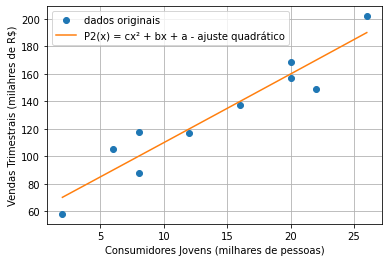

In [14]:
import numpy as np
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
A2 = [[0., 0., 0.],[0., 0., 0.], [0., 0., 0.]]  # matriz dos coeficientes do sistema linear
B2 = [0., 0., 0.]

for i in range(len(x)):
  A2[0][0] +=1
  A2[1][1] += x[i]*x[i]
  A2[2][2] += (x[i]*x[i])**2
  A2[0][1] += x[i]
  A2[0][2] += x[i]**2
  A2[1][2] += x[i]**3
  B2[0] += f[i]
  B2[1] += x[i]*f[i]
  B2[2] += (x[i]**2)*f[i]

A2[1][0] = A2[0][1]
A2[2][0] = A2[0][2]
A2[2][1] = A2[1][2]

[a2, b2, c2] = np.linalg.solve(A2, B2)   # resolucao do sistema linear

# definicao da funcao de ajustamento
def P2(c,b,a,t):
  return c*t*t + b*t + a

# impressao da funcao de ajuste
print('P2(x) = ' ,c2,'*x^2 +' ,b2,'*x + ',a2, '   =>\nP2(30) = ',P2(c2,b2,a2,30),'\n')

#grafico com a função de ajustamento e os dados originais
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P2(c2,b2,a2,y)) 
plt.legend(['dados originais','P2(x) = cx² + bx + a - ajuste quadrático'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milahres de R$)') 
plt.grid()
plt.show()

A função de ajustamento $P_2(x)$, apesar de ser formalmente um polinômio quadrático, apresenta um comportamento muito mais próximo de uma reta no intervalo analisado (visto que o coeficiente que multiplica o termo quadrático $<<1$).





















*(c)* Assuma uma equação de ajustamento da forma $P(x) = ag_1(x) + bg_0(x)$, onde $g_1(x) = ln(x)$ e $g_0(x) = 1$, o que resulta na montagem da seguinte tabela:  
\begin{array}{c|ccccccccc}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$g_0$} &\text{$g_1$} &\text{$g^2_0$}&\text{$g^2_1$}&\text{$g_0g_1$}&\text{$g_0f(x_i)$}&\text{$g_1f(x_i)$}\\ \hline 
0 & 2 & 58 & 1 & 0.693147181 & 1 & 0.480453014 & 0.693147181 & 58 & 40.20253647\\
1 & 6 & 105 & 1 & 1.791759469 & 1 & 3.210401996 & 1.791759469 & 105 & 188.1347443\\
2 & 8 & 88 & 1 & 2.079441542 & 1 & 4.324077125 & 2.079441542 & 88 & 182.9908557\\
3 & 8 & 118 & 1 & 2.079441542 & 1 & 4.324077125 & 2.079441542 & 118 & 245.3741019\\
4 & 12 & 117 & 1 & 2.48490665 & 1 & 6.174761058 & 2.48490665 & 117 & 290.734078\\
5 & 16 & 137 & 1 & 2.772588722 & 1 & 7.687248223 & 2.772588722 & 137 & 379.8446549\\
6 & 20 & 157 & 1 & 2.995732274 & 1 & 8.974411855 & 2.995732274 & 157 & 470.3299669\\
7 & 20 & 169 & 1 & 2.995732274 & 1 & 8.974411855 & 2.995732274 & 169 & 506.2787542\\
8 & 22 & 149 & 1 & 3.091042453 & 1 & 9.554543448 & 3.091042453 & 149 & 460.5653256\\
9 & 26 & 202 & 1 & 3.258096538 & 1 & 10.61519305 & 3.258096538 & 202 & 658.1355007\\
\hline
 &  &  &  & \text{$\Sigma =$} & 10 & 64.31957875 & 24.24188864 & 1300 & 3422.590519
\end{array}
 
 Portanto, será necessario resolver o sistema de equações lineares: 

 $\left\{
\begin{aligned}
    10a + 24.24188864b     &= 1330\\
    24.24188864a + 64.31957875b &= 3422.590519
\end{aligned}
\right.$

Cuja solução é $a = 11.62314794$ e $b = 48.83153033$, de maneira que a função de ajustamento tem a forma $P(x) = 48.83153033ln(x) +11.62314794 $ e a projeção de vendas com 30.000 pessoas é de $P(30) = 48.83153033ln(30) +11.62314794 = 177.708821$.

P3(x) =  48.83153033285429 * ln(x)  +  11.623147937128273    =>
P3(30) =  177.7088210477884 



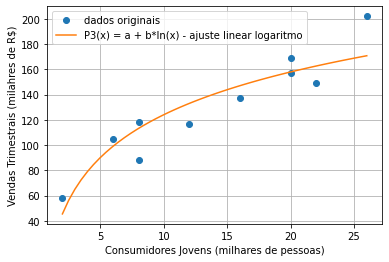

In [15]:
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
A3 = [[0., 0.],[0., 0.]]  # matriz dos coeficientes do sistema linear
B3 = [0., 0.]

for i in range(len(x)):
  A3[0][0] +=1
  A3[1][1] += np.log(x[i])*np.log(x[i])
  A3[0][1] += np.log(x[i])
  B3[0] += f[i]
  B3[1] += np.log(x[i])*f[i]
A3[1][0] = A3[0][1]

[b3, a3] = np.linalg.solve(A3, B3)  # solucao do sistema de equacoes

#definicao da funcao de ajuste
def P3(a,b,t):
  return a*np.log(t) + b

# impressao da funcao de ajuste
print('P3(x) = ',a3,'* ln(x)  + ',b3, '   =>\nP3(30) = ',P3(a3,b3,30),'\n')

#grafico com a função de ajustamento e os dados originais
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P3(a3,b3,y)) 
plt.legend(['dados originais','P3(x) = a + b*ln(x) - ajuste linear logaritmo'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milahres de R$)') 
plt.grid()
plt.show()

*(d)* Quando tentamos comparar os resultados dos ajustamentos, a primeira ideia é fazer um gráfico sobre os dados originais das funções de ajustamento $P_1(x)$,  $P_2(x)$ e $P_3(x)$:

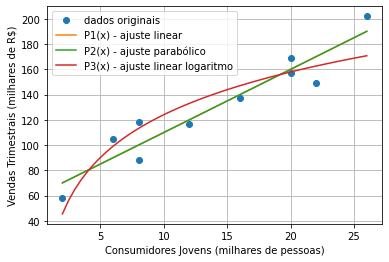

In [16]:
plt.plot(x,f,'o',y,P1(a1,b1,y),y,P2(c2,b2,a2,y),y,P3(a3,b3,y))
plt.legend(['dados originais','P1(x) - ajuste linear','P2(x) - ajuste parabólico','P3(x) - ajuste linear logaritmo']) 
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milhares de R$)') 
plt.grid()
plt.show()

$P_1(x)$ e $P_2(x)$ são tão próximas, que graficamente não há como notar diferenças entre elas (estão praticamente superpostas na curva verde). A curva em vermelho é a função $P_3(x)$. 

*Como então diferenciar e tomar uma decisão, por qual função de ajustamento utilizar?*

A resposta está na soma quadrática dos resíduos. Na estatística, o coeficente $r^2$ mede a qualidade do ajustamento, sendo tão melhor quanto mais próximo de 1, tal que:

$r^2 = 1 - \frac{\sum_{i=1}^n (P(x_i) - f(x_i))^2}{\sum_{i=1}^n (P(x_i) - \bar{f})^2 + \sum_{i=1}^n (P(x_i) - f(x_i))^2}  = 1 - \frac{\sum_{i=1}^n Res^2(x_i)}{\sum_{i=1}^n (P(x_i) - \bar{f})^2 + \sum_{i=1}^n Res^2(x_i)}$, 

onde $\bar{f} = \frac{1}{n}\sum_{i=1}^n f(x_i)$, e $Res(x_i)$ é o resíduo no ponto $x_i$. A tabela abaixo mostra os valores necessários para calcular $r^2$.


\begin{array}{c|lllllllllll}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$P_1$} &\text{$P_2$} &\text{$P_3$}&\text{$(P_1 - \bar{f})^2$}&\text{$(P_2 - \bar{f})^2$}&\text{$(P_3 - \bar{f})^2$}&\text{$[P_1 - f(x_i)]^2$}&\text{$[P_2 - f(x_i)]^2$} &\text{$[P_3 - f(x_i)]^2$}\\ \hline 
0 & 2 & 58 & 70 & 70.09252971 & 45.47058551 & 3600 & 3588.904996 & 7145.221914 & 144 & 146.2292748 & 156.9862275\\
1 & 6 & 105 & 90 & 90.00764007 & 99.11750481 & 1600 & 1599.388853 & 953.7285093 & 225 & 224.7708563 & 34.60374968\\
2 & 8 & 88 & 100 & 99.97792869 & 113.1654607 & 900 & 901.3247656 & 283.401715 & 144 & 143.4707758 & 633.30041\\
3 & 8 & 118 & 100 & 99.97792869 & 113.1654607 & 900 & 901.3247656 & 283.401715 & 324 & 324.7950542 & 23.37277068\\
4 & 12 & 117 & 120 & 119.9439728 & 132.9649424 & 100 & 101.1236823 & 8.79088332 & 9 & 8.666976055 & 254.8793852\\
5 & 16 & 137 & 140 & 139.9439728 & 147.0128982 & 100 & 98.88259575 & 289.4387061 & 9 & 8.666976055 & 100.2581309\\
6 & 20 & 157 & 160 & 159.9779287 & 157.9093393 & 900 & 898.6762087 & 778.9312214 & 9 & 8.868059299 & 0.826898003\\
7 & 20 & 169 & 160 & 159.9779287 & 157.9093393 & 900 & 898.6762087 & 778.9312214 & 81 & 81.39777067 & 123.0027543\\
8 & 22 & 149 & 170 & 170.0076401 & 162.5634813 & 1600 & 1600.611264 & 1060.380312 & 441 & 441.3209412 & 183.9680238\\
9 & 26 & 202 & 190 & 190.0925297 & 170.7209879 & 3600 & 3611.112127 & 1658.198852 & 144 & 141.7878487 & 978.3766004\\
\hline
 &  &  &  &  & \text{$\Sigma =$}  & 14200 & 14200.02547 & 13240.42505 & 1530 & 1529.974533 & 2489.57495
\end{array}

Então: 
*   $r^2_{P_1} = 1 - \frac{1530}{1530+14200} = 0.9027336300063573$
*   $r^2_{P_2} = 1 - \frac{1529.9745330}{1529.974533+14200.02547} = 0.8964161717801634$
*   $r^2_{P_3} = 1 - \frac{2489.57495}{2489.57495+13240.42505} = 0.8417307723799871$

Sob o ponto de vista estatístico, $r^2_{P_1} > r^2_{P_2} > r^2_{P_3}$, portanto $P_1(x)$ é a função dentre as três analisadas, que melhor ajusta os dados. 


In [17]:
import numpy as np
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
R2_p1 = 0.; R2_p2 = 0.; R2_p3 = 0.
f_med = 0.
aux1_p1 = 0.; aux2_p1 = 0.
aux1_p2 = 0.; aux2_p2 = 0.
aux1_p3 = 0.; aux2_p3 = 0.

# calculo da media
for i in range(len(x)):
  f_med += f[i]
f_med = f_med/n

for i in range(len(x)):
  aux1_p1 += (P1(a1,b1,x[i]) - f[i])**2
  aux1_p2 += (P2(c2,b2,a2,x[i]) - f[i])**2
  aux1_p3 += (P3(a3,b3,x[i]) - f[i])**2
  aux2_p1 += (P1(a1,b1,x[i]) - f_med)**2
  aux2_p2 += (P2(c2,b2,a2,x[i]) - f_med)**2
  aux2_p3 += (P3(a3,b3,x[i]) - f_med)**2

# calculo do coeficiente R²
R2_p1 = 1 - aux1_p1/(aux1_p1 + aux2_p1)
R2_p2 = 1 - aux1_p2/(aux1_p2 + aux2_p3)
R2_p3 = 1 - aux1_p3/(aux1_p3 + aux2_p3)

# impressao do coeficientes encontrados
print('R2_P1(x) = ', R2_p1, '\nR2_P2(x) = ', R2_p2, '\nR2_P3(x) = ', R2_p3)
  

R2_P1(x) =  0.9027336300063573 
R2_P2(x) =  0.8964161717801634 
R2_P3(x) =  0.8417307723799871


# Ajustamento Não Linear: questão 2

Faça a mesma análise da questão anterior, para as seguintes funções de ajustamento:

*   (a) $P_4(x) = ae^{bx}$
*   (b) $P_5(x) = \sqrt{a + bx}$
*   (c) $P_6(x) = \frac{1}{a + bx}$



Observa-se que neste caso, as funções  de ajustamento $P_4$, $P_5$ e $P_6$ são não lineares, pois a dependência de $P$ é não linear com respeito aos parâmetros *a* e *b*.

Nestes três casos, é possível aplicar uma *transformação* de maneira a tornar o problema linear novamente (com respeito aos parâmetros *a* e *b*). São elas:


*   Para $P_4(x)$, aplique o $ln()$, de forma que a nova função de ajustamento será $P'_4(x) = ln(P_4(x)) = ln(a) + b*x = a' + bx$.
*   Para $P_5(x)$, eleve ao quadrado, de forma que a nova função de ajustamento será $P'_5(x) = P_5^2(x) = a + b*x $.
*    Para $P_6(x)$, eleve a -1, de forma que a nova função de ajustamento será $P'_6(x) = \frac{1}{P_6(x)} = a + b*x $.

As transformações aplicadas na função de ajustamento também devem ser aplicadas ao tabelamento, por exemplo, no caso de $P'_6(x)$, o tabelamento será com $\frac{1}{f(x)}$ ao invés de $f(x)$. 

Os casos de funções de ajustamento $P(x)$, em que NÃO é possível uma transformação que leve à uma forma linear, por exemplo $P(x) = b^{acx}$, onde *a*, *b*, e *c* são parâmetros, não serão tratados neste curso.




*(a)* Assuma uma equação de ajustamento da forma $P'(x) = ln (P(x))= a'g_0(x) + bg_1(x)$, onde $g_0(x) = 1$ e $g_1(x) = x$, o que resulta na montagem da seguinte tabela:  
\begin{array}{c|cccccccccc}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$ln[f(x_i)]$}&\text{$g_0$} &\text{$g_1$} &\text{$g^2_0$}&\text{$g^2_1$}&\text{$g_0g_1$}&\text{$g_0ln[f(x_i)]$}&\text{$g_1ln[f(x_i)]$}\\ \hline 
0 & 2 & 58 & 4.060443011 & 1 & 2 & 1 & 4 & 2 & 4.060443011 & 8.120886021\\
1 & 6 & 105 & 4.65396035 & 1 & 6 & 1 & 36 & 6 & 4.65396035 & 27.9237621\\
2 & 8 & 88 & 4.477336814 & 1 & 8 & 1 & 64 & 8 & 4.477336814 & 35.81869452\\
3 & 8 & 118 & 4.770684624 & 1 & 8 & 1 & 64 & 8 & 4.770684624 & 38.165477\\
4 & 12 & 117 & 4.762173935 & 1 & 12 & 1 & 144 & 12 & 4.762173935 & 57.14608722\\
5 & 16 & 137 & 4.919980926 & 1 & 16 & 1 & 256 & 16 & 4.919980926 & 78.71969481\\
6 & 20 & 157 & 5.056245805 & 1 & 20 & 1 & 400 & 20 & 5.056245805 & 101.1249161\\
7 & 20 & 169 & 5.129898715 & 1 & 20 & 1 & 400 & 20 & 5.129898715 & 102.5979743\\
8 & 22 & 149 & 5.003946306 & 1 & 22 & 1 & 484 & 22 & 5.003946306 & 110.0868187\\
9 & 26 & 202 & 5.308267697 & 1 & 26 & 1 & 676 & 26 & 5.308267697 & 138.0149601\\
\hline
 &  &  &  &  & \text{$\Sigma$} & 10 & 2528 & 140 & 48.14293818 & 697.7192709
\end{array}
 
 Portanto, será necessario resolver o sistema de equações lineares: 

 $\left\{
\begin{aligned}
    10a' + 140b     &= 48.14293818\\
    140a' + 2528b &= 697.7192709
\end{aligned}
\right.$

Cuja solução é $a'= ln(a) = 4.229691866$ e $b = 0.041757282$, portanto $a = e^{4.229691866} = 68.69606131248608$,  de maneira que a função de ajustamento tem a forma $P_4(x) = 68.69606131248608e^{0.04175728232145544x}$ e a projeção de vendas com 30.000 pessoas é de $P_4(30) = 240.42551569628966$.

P4(x) =  68.69606131248608 e^{ 0.04175728232145544 x    =>
P4(30) =  240.42551569628966
R²_P4(x) =  0.9007944732073859 



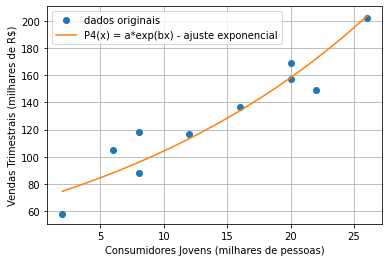

In [18]:
import numpy as np
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
A4 = [[0., 0.],[0., 0.]]  # matriz dos coeficientes do sistema linear
B4 = [0., 0.]

for i in range(len(x)):
  A4[0][0] +=1
  A4[1][1] += x[i]*x[i]
  A4[0][1] += x[i]
  B4[0] += np.log(f[i])
  B4[1] += x[i]*np.log(f[i])
A4[1][0] = A4[0][1]

[a4, b4] = np.linalg.solve(A4, B4)   # resolucao do sistema linear

# definicacao da função exponencial
def P4(b,a,t):
  return a*np.exp(b*t)

a4 = np.exp(a4)
print('P4(x) = ' ,a4,'e^{',b4,'x', '   =>\nP4(30) = ',P4(b4,a4,30))

# calculo de R²
R2_p4 = 0.
f_med = 0.
aux1_p4 = 0.; aux2_p4 = 0.

for i in range(len(x)): # calculo da media
  f_med += f[i]
f_med = f_med/n

for i in range(len(x)):
  aux1_p4 += (P4(b4,a4,x[i]) - f[i])**2
  aux2_p4 += (P4(b4,a4,x[i]) - f_med)**2

R2_p4 = 1 - aux1_p4/(aux1_p4 + aux2_p4)
print('R²_P4(x) = ', R2_p4,'\n')  # imprime R² de P4(x)

# grafico do ajuste
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P4(b4,a4,y)) 
plt.legend(['dados originais','P4(x) = a*exp(bx) - ajuste exponencial'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milhares de R$)') 
plt.grid()
plt.show()

*(b)* Assuma uma equação de ajustamento da forma $P'(x) = P^2(x)= ag_0(x) + bg_1(x)$, onde $g_0(x) = 1$ e $g_1(x) = x$, o que resulta na montagem da seguinte tabela:  
\begin{array}{c|cccccccccc}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$f^2(x_i)$}&\text{$g_0$} &\text{$g_1$} &\text{$g^2_0$}&\text{$g^2_1$}&\text{$g_0g_1$}&\text{$g_0f^2(x_i)$}&\text{$g_1f^2(x_i)$}\\ \hline 
0 & 2 & 58 & 3364 & 1 & 2 & 1 & 4 & 2 & 3364 & 6728\\ 
1 & 6 & 105 & 11025 & 1 & 6 & 1 & 36 & 6 & 11025 & 66150\\
2 & 8 & 88 & 7744 & 1 & 8 & 1 & 64 & 8 & 7744 & 61952\\
3 & 8 & 118 & 13924 & 1 & 8 & 1 & 64 & 8 & 13924 & 111392\\
4 & 12 & 117 & 13689 & 1 & 12 & 1 & 144 & 12 & 13689 & 164268\\
5 & 16 & 137 & 18769 & 1 & 16 & 1 & 256 & 16 & 18769 & 300304\\
6 & 20 & 157 & 24649 & 1 & 20 & 1 & 400 & 20 & 24649 & 492980\\
7 & 20 & 169 & 28561 & 1 & 20 & 1 & 400 & 20 & 28561 & 571220\\
8 & 22 & 149 & 22201 & 1 & 22 & 1 & 484 & 22 & 22201 & 488422\\
9 & 26 & 202 & 40804 & 1 & 26 & 1 & 676 & 26 & 40804 & 1060904\\
\hline
 &  &  &  &  & \text{$\Sigma = $} & 10 & 2528 & 140 & 184730 & 3324320
\end{array}
 
 Portanto, será necessario resolver o sistema de equações lineares: 

 $\left\{
\begin{aligned}
    10a + 140b     &= 184730\\
    140a + 2528b &= 3324320
\end{aligned}
\right.$

Cuja solução é $a = 280.3943662$ e $b = 1299.471831$, portanto $P_5(x) = \sqrt{280.3943662 + 1299.471831x}$ e a projeção de vendas com 30.000 pessoas é de $P_5(30) = 198.1528432694687$.

P5(x) =  sqrt( 280.3943661971806  +  1299.4718309859156 x)    =>
P5(30) =  198.15284326946875
R²_P5(x) =  0.9045787441759416 



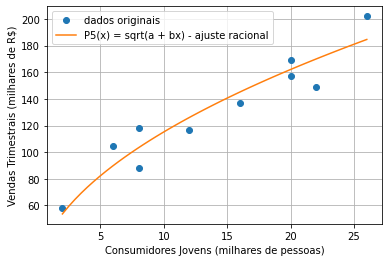

In [19]:
import numpy as np
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
A5 = [[0., 0.],[0., 0.]]  # matriz dos coeficientes do sistema linear
B5 = [0., 0.]

for i in range(len(x)):
  A5[0][0] +=1
  A5[1][1] += x[i]*x[i]
  A5[0][1] += x[i]
  B5[0] += f[i]**2
  B5[1] += x[i]*f[i]**2
A5[1][0] = A5[0][1]

[a5, b5] = np.linalg.solve(A5, B5)   # resolucao do sistema linear

# definicao da função exponencial
def P5(b,a,t):
  return np.sqrt(a + b*t)

print('P5(x) =  sqrt(' ,a5,' + ',b5,'x)', '   =>\nP5(30) = ',P5(b5,a5,30))

# calculo de R²
R2_p5 = 0.
f_med = 0.
aux1_p5 = 0.; aux2_p5 = 0.
# calculo da media
for i in range(len(x)):
  f_med += f[i]
f_med = f_med/n

for i in range(len(x)):
  aux1_p5 += (P5(b5,a5,x[i]) - f[i])**2
  aux2_p5 += (P5(b5,a5,x[i]) - f_med)**2

R2_p5 = 1 - aux1_p5/(aux1_p5 + aux2_p5)
print('R²_P5(x) = ', R2_p5,'\n')  # imprime R² de P5(x)

# grafico do ajuste
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P5(b5,a5,y)) 
plt.legend(['dados originais','P5(x) = sqrt(a + bx) - ajuste racional'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milhares de R$)') 
plt.grid()
plt.show()

*(c)* Assuma uma equação de ajustamento da forma $P'(x) = \frac{1}{P(x)}= ag_0(x) + bg_1(x)$, onde $g_0(x) = 1$ e $g_1(x) = x$, o que resulta na montagem da seguinte tabela:  
\begin{array}{c|cccccccccc}
\text{i}&\text{$x_i$}&\text{$f(x_i)$}&\text{$\frac{1}{f(x_i)}$}&\text{$g_0$} &\text{$g_1$} &\text{$g^2_0$}&\text{$g^2_1$}&\text{$g_0g_1$}&\text{$\frac{g_0}{f(x_i)}$}&\text{$\frac{g_1}{f(x_i)}$}\\ \hline 
0 & 2 & 58 & 0.017241379 & 1 & 2 & 1 & 4 & 2 & 0.017241379 & 0.034482759\\
1 & 6 & 105 & 0.00952381 & 1 & 6 & 1 & 36 & 6 & 0.00952381 & 0.057142857\\
2 & 8 & 88 & 0.011363636 & 1 & 8 & 1 & 64 & 8 & 0.011363636 & 0.090909091\\
3 & 8 & 118 & 0.008474576 & 1 & 8 & 1 & 64 & 8 & 0.008474576 & 0.06779661\\
4 & 12 & 117 & 0.008547009 & 1 & 12 & 1 & 144 & 12 & 0.008547009 & 0.102564103\\
5 & 16 & 137 & 0.00729927 & 1 & 16 & 1 & 256 & 16 & 0.00729927 & 0.116788321\\
6 & 20 & 157 & 0.006369427 & 1 & 20 & 1 & 400 & 20 & 0.006369427 & 0.127388535\\
7 & 20 & 169 & 0.00591716 & 1 & 20 & 1 & 400 & 20 & 0.00591716 & 0.118343195\\
8 & 22 & 149 & 0.006711409 & 1 & 22 & 1 & 484 & 22 & 0.006711409 & 0.147651007\\
9 & 26 & 202 & 0.004950495 & 1 & 26 & 1 & 676 & 26 & 0.004950495 & 0.128712871\\
\hline
 &  &  &  &  & \text{$\Sigma$} & 10 & 2528 & 140 & 0.086398171 & 0.991779349
\end{array}
 
 Portanto, será necessario resolver o sistema de equações lineares: 

 $\left\{
\begin{aligned}
    10a + 140b     &= 0.086398171\\
    140a + 2528b &= 0.991779349
\end{aligned}
\right.$

Cuja solução é $a  = 0.01400800485402822$ e $b = -0.0003834419820779978$, de maneira que a função de ajustamento tem a forma $P_6(x) = \frac{1}{0.01400800485402822 - 0.0003834419820779978x}$ e a projeção de vendas com 30.000 pessoas é de $P_6(30) = 399.24217579894$.

P5(x) =  1/( 0.01400800485402822  +  -0.0003834419820779978 x)    =>
P6(30) =  399.24217579894
R²_P6(x) =  0.846892380425856 



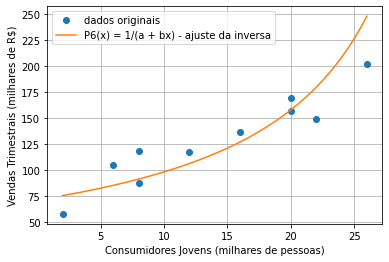

In [20]:
import numpy as np
x = [2, 6, 8, 8, 12, 16, 20, 20, 22, 26] 
n = len(x)
f = [58, 105,88, 118, 117, 137, 157, 169, 149, 202]
A6 = [[0., 0.],[0., 0.]]  # matriz dos coeficientes do sistema linear
B6 = [0., 0.]

for i in range(len(x)):
  A6[0][0] +=1
  A6[1][1] += x[i]*x[i]
  A6[0][1] += x[i]
  B6[0] += f[i]**(-1)
  B6[1] += x[i]*(f[i]**(-1))
A6[1][0] = A6[0][1]

[a6, b6] = np.linalg.solve(A6, B6)   # resolucao do sistema linear

# definicao da função exponencial
def P6(b,a,t):
  return (a + b*t)**(-1)

print('P5(x) =  1/(' ,a6,' + ',b6,'x)', '   =>\nP6(30) = ',P6(b6,a6,30))

# calculo de R²
R2_p6 = 0.
f_med = 0.
aux1_p6 = 0.; aux2_p6 = 0.
# calculo da media
for i in range(len(x)):
  f_med += f[i]
f_med = f_med/n

for i in range(len(x)):
  aux1_p6 += (P6(b6,a6,x[i]) - f[i])**2
  aux2_p6 += (P6(b6,a6,x[i]) - f_med)**2

R2_p6 = 1 - aux1_p6/(aux1_p6 + aux2_p6)
print('R²_P6(x) = ', R2_p6,'\n')  # imprime R² de P6(x)

# grafico do ajuste
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P6(b6,a6,y)) 
plt.legend(['dados originais','P6(x) = 1/(a + bx) - ajuste da inversa'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milhares de R$)') 
plt.grid()
plt.show()

Quando juntamos os resultados dos esboços do gráficos de ajuste e dos coeficientes $r^2$, tem-se que:

R²_P4(x) =  0.9007944732073859
R²_P5(x) =  0.9045787441759416
R²_P6(x) =  0.846892380425856

A curva com melhor ajuste foi P5(x), com maior R²!



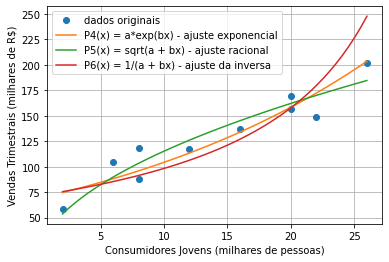

In [21]:
print('R²_P4(x) = ', R2_p4)  # imprime R² de P6(x)
print('R²_P5(x) = ', R2_p5)  # imprime R² de P6(x)
print('R²_P6(x) = ', R2_p6)  # imprime R² de P6(x)
print('\nA curva com melhor ajuste foi P5(x), com maior R²!\n')

# grafico do ajuste
import matplotlib.pyplot as plt  # biblioteca para plotar gráficos
y = np.linspace(x[0],x[n-1]) #limites no eixo x
plt.plot(x,f,'o',y,P4(b4,a4,y),y,P5(b5,a5,y),y,P6(b6,a6,y)) 
plt.legend(['dados originais','P4(x) = a*exp(bx) - ajuste exponencial','P5(x) = sqrt(a + bx) - ajuste racional','P6(x) = 1/(a + bx) - ajuste da inversa'])
plt.xlabel('Consumidores Jovens (milhares de pessoas)') 
plt.ylabel('Vendas Trimestrais (milhares de R$)') 
plt.grid()
plt.show()
